# Theory vs Experiment — Barske pump (Lock model)

All overlays in one place, fully tunable. **Edit the parameters cell** (K, eta_losses,
throat dia, seal friction) and re-run. Lock model lives in `prop_components/barskepump.py`
(`analyse_lock`, `efficiency_lock`), validated to machine precision against DynamicPumps.

In [1]:
%matplotlib inline
import sys, numpy as np, h5py, matplotlib.pyplot as plt
from scipy.optimize import least_squares
sys.path.insert(0, r'C:\\Users\\Martin\\Active\\FYPTurbine')
sys.path.insert(0, r'C:\\Users\\Martin\\Active\\FYPTurbine\\data_analysis')
import epump_io as ep, cav_video as cv
from prop_components.barskepump import BarskePump
from mech_components.bearing import Bearing
from mech_components.mechanicalseal import MechanicalSeal

## Tunable parameters — edit here

In [2]:
# --- TUNE THESE ---
K_DEFAULT   = 0.17      # Lock prerotation factor (literature)
ETAL_DEFAULT= 0.194     # Lock diffuser loss fraction (literature)
D3_MM       = 3.8       # as-built diffuser throat diameter [mm]
DINLET_MM   = 19.54     # fluid-entrance (eye) diameter [mm]
SEAL_F      = 0.014     # fitted seal friction coeff (water film; default 0.07 is dry)
P_INLET     = 3.0e5     # inlet static pressure for throat/cutoff [Pa]
RHO, G      = 998.0, 9.81

LOGDIR = r'D:\\Projects\\propbackend_logs\\2026-06-02\\hotfirelog'
RUNS = {'30%':'20260602_150821','35%':'20260602_152153','40%':'20260602_153853',
        '45%':'20260602_162513','50%':'20260602_163135'}
D2, B2 = 0.058522, 0.003554   # impeller tip dia, outlet width [m]
D3, DINLET = D3_MM/1000, DINLET_MM/1000
# measured shaft-only parasitic torque (rpm, Nm) -> power
MEAS = [(3722,0.0160),(4011,0.0099),(4101,0.0107),(4159,0.0103),(6739,0.0112),(8699,0.0151)]
MR = np.array([m[0] for m in MEAS]); MP = np.array([m[1]*m[0]*np.pi/30 for m in MEAS])

In [3]:
# build pump object with fitted seal friction
tb = Bearing(d=10,D=22,series=619,visc=1.0,C_0_kN=1.27,submerged=False)
bb = Bearing(d=10,D=22,series=619,visc=1.0,C_0_kN=1.27,submerged=True)
seal = MechanicalSeal(OD_mm=19.5,ID_mm=15,BD_mm=14,F_sp=100,f=SEAL_F)
pump = BarskePump(0.3,20e5,1000,1.002e-6,20000,tb,bb,seal)
def lock(Q,RPM,K,eL): return pump.analyse_lock(Q,RPM=RPM,D_3=D3,D_inlet=DINLET,
                                               K_factor=K,eta_losses=eL,p_inlet=P_INLET)

## Load experimental H-Q (all speeds)

In [4]:
EXP = {}
for lbl,tag in RUNS.items():
    d = ep.load(ep.find_runs(LOGDIR)[tag]); r = ep.analyse_hq(tag,d)
    if r is not None:
        EXP[lbl] = dict(q=np.array(r['qbin']), H=np.array(r['Hbin']), N=r['rpm'], d=d, tag=tag)
print('loaded', list(EXP))

loaded ['30%', '35%', '40%', '45%', '50%']


## Fit K & eta_losses to the psi-phi collapse

In [5]:
PHI=[]; PSI=[]
for e in EXP.values():
    u2=np.pi*D2*e['N']/60
    PHI += list(e['q']/1000/(np.pi*D2*B2*u2)); PSI += list(2*G*e['H']/u2**2)
PHI=np.array(PHI); PSI=np.array(PSI)
Nref=7483; u2r=np.pi*D2*Nref/60
def lock_psi(phi,K,eL):
    Q=phi*np.pi*D2*B2*u2r
    return 2*G*np.asarray(lock(Q,Nref,K,eL)['H_static'])/u2r**2
fit=least_squares(lambda p: lock_psi(PHI,p[0],p[1])-PSI, x0=[0.17,0.194], bounds=([0,0],[1.5,2.0]))
K_FIT, ETAL_FIT = fit.x
print(f'fitted K={K_FIT:.3f}  eta_losses={ETAL_FIT:.3f}  (note: eta_losses railing => cutoff is throat-cavitation-limited, not diffuser-loss)')

fitted K=0.441  eta_losses=2.000  (note: eta_losses railing => cutoff is throat-cavitation-limited, not diffuser-loss)


## 1. H-Q & psi-phi: theory vs experiment (default dotted, tuned solid)

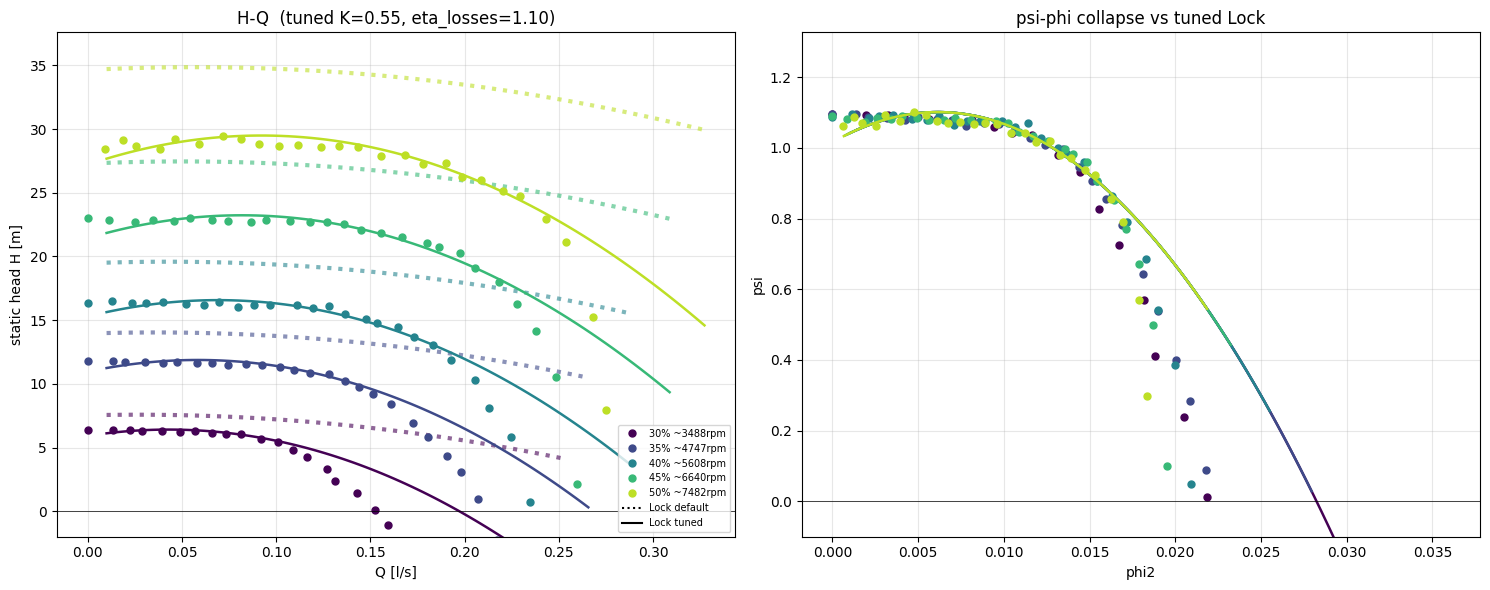

In [17]:
# K_FIT = 0.17; ETAL_FIT = 0.194 # Defaults
K_FIT = 0.55; ETAL_FIT = 1.1

fig,(a1,a2)=plt.subplots(1,2,figsize=(15,6)); cols=plt.cm.viridis(np.linspace(0,0.9,len(EXP)))
for (lbl,e),c in zip(EXP.items(),cols):
    q=e['q']; H=e['H']; N=e['N']; u2=np.pi*D2*N/60
    a1.plot(q,H,'o',color=c,ms=5,label=f'{lbl} ~{N:.0f}rpm')
    qth=np.linspace(1e-5,q.max()/1000*1.15,80)
    a1.plot(qth*1000,lock(qth,N,K_DEFAULT,ETAL_DEFAULT)['H_static'],':',color=c,lw=3,alpha=.6)
    a1.plot(qth*1000,lock(qth,N,K_FIT,ETAL_FIT)['H_static'],'-',color=c,lw=1.8)
    a2.plot(q/1000/(np.pi*D2*B2*u2),2*G*H/u2**2,'o',color=c,ms=5)
    a2.plot(qth/(np.pi*D2*B2*u2),2*G*lock(qth,N,K_FIT,ETAL_FIT)['H_static']/u2**2,'-',color=c,lw=1.8)
a1.plot([],[],'k:',label='Lock default'); a1.plot([],[],'k-',label='Lock tuned')
a1.set(xlabel='Q [l/s]',ylabel='static head H [m]',ylim=(-2,None)); a1.axhline(0,color='k',lw=.5); a1.grid(alpha=.3); a1.legend(fontsize=7)
a1.set_title(f'H-Q  (tuned K={K_FIT:.2f}, eta_losses={ETAL_FIT:.2f})')
a2.set(xlabel='phi2',ylabel='psi',ylim=(-0.1,None)); a2.axhline(0,color='k',lw=.5); a2.grid(alpha=.3); a2.set_title('psi-phi collapse vs tuned Lock')
plt.tight_layout(); plt.show()

## 2. Efficiency: theory vs measured

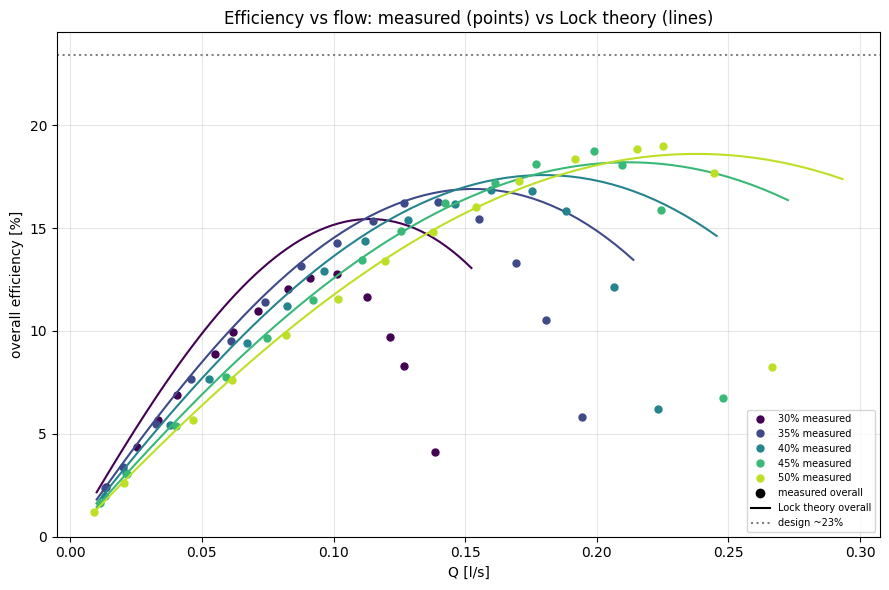

In [19]:
fig,ax=plt.subplots(figsize=(9,6)); cols=plt.cm.viridis(np.linspace(0,0.9,len(EXP)))
for (lbl,e),c in zip(EXP.items(),cols):
    d=e['d']; t=d['t']; m=(t>=0.5)&(t<=20)
    Q=d['q'][m]/1000; H=ep.head_m(d['pout'][m]-d['pin'][m]); rpm=d['rpm'][m]; w=rpm*2*np.pi/60; tq=d['tq'][m]
    Phyd=RHO*G*Q*H; Psh=tq*w; Ppar=np.interp(rpm,MR,MP)
    good=(rpm>2000)&(Psh>0)&(H>0)&(Q>0)
    Q,Phyd,Psh,Ppar=Q[good],Phyd[good],Psh[good],Ppar[good]
    eo=Phyd/Psh
    qb=np.linspace(0,np.nanpercentile(Q*1000,98),16); idx=np.digitize(Q*1000,qb); qc=[];ec=[]
    for i in range(1,len(qb)):
        s=idx==i
        if s.sum()>=5: qc.append(np.median(Q[s]*1000)); ec.append(np.median(eo[s])*100)
    ax.plot(qc,ec,'o',color=c,ms=5,label=f'{lbl} measured')
    # theory (tuned)
    qth=np.linspace(1e-5,(max(qc)/1000 if qc else 2e-4)*1.1,60)
    et=pump.efficiency_lock(qth,RPM=e['N'],D_3=D3,D_inlet=DINLET,K_factor=K_FIT,eta_losses=ETAL_FIT, disk_mult=2.5) 
    ax.plot(qth*1000,np.asarray(et['eta_ovr'])*100,'-',color=c,lw=1.5)
ax.plot([],[],'ko',label='measured overall'); ax.plot([],[],'k-',label='Lock theory overall')
ax.axhline(23.4,color='gray',ls=':',label='design ~23%')
ax.set(xlabel='Q [l/s]',ylabel='overall efficiency [%]',ylim=(0,None)); ax.grid(alpha=.3); ax.legend(fontsize=7)
ax.set_title('Efficiency vs flow: measured (points) vs Lock theory (lines)'); plt.tight_layout(); plt.show()

## 3. Cavitation: Lock throat NPSHr vs experiment
Lock's throat model predicts cavitation only at **high flow** (the cutoff). It does NOT
predict the low-flow suction NPSHr you measured — different regimes. Both shown.

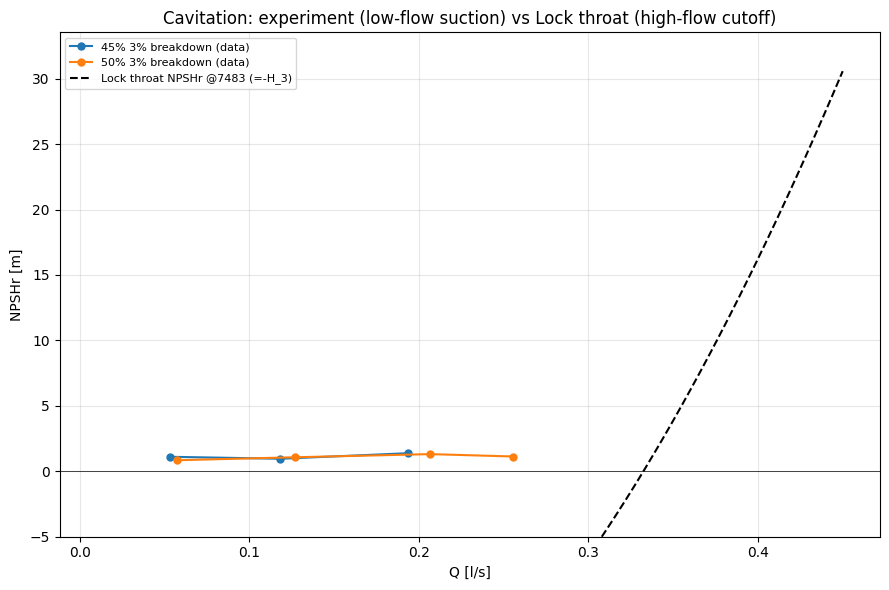

In [8]:
fig,ax=plt.subplots(figsize=(9,6))
# experimental: data 3% breakdown + video throat onset
for lbl,tag in [('45%','20260602_162513'),('50%','20260602_163135')]:
    d=ep.load(ep.find_runs(LOGDIR)[tag]); cav=ep.analyse_cav(tag,d)
    pts=sorted((s['q_ref'],s['npshr']) for s in cav['steps'] if s.get('broke') and np.isfinite(s['npshr']))
    if pts: q,n=zip(*pts); ax.plot(q,n,'o-',ms=5,label=f'{lbl} 3% breakdown (data)')
# Lock throat NPSHr curve at a representative speed
qth=np.linspace(1e-5,0.45e-3,80)
lk=lock(qth,7483,K_FIT,ETAL_FIT)
ax.plot(qth*1000, lk['NPSHr_throat'],'k--',label='Lock throat NPSHr @7483 (=-H_3)')
ax.axhline(0,color='k',lw=.5)
ax.set(xlabel='Q [l/s]',ylabel='NPSHr [m]',ylim=(-5,None)); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title('Cavitation: experiment (low-flow suction) vs Lock throat (high-flow cutoff)')
plt.tight_layout(); plt.show()

## 4. Turbine-driven coupled H-Q (proof of concept)
Pump driven by the turbine (not the motor). If the H-Q lands on the motor-driven curve at
matched rpm, the integrated turbopump performs identically to the bench pump.

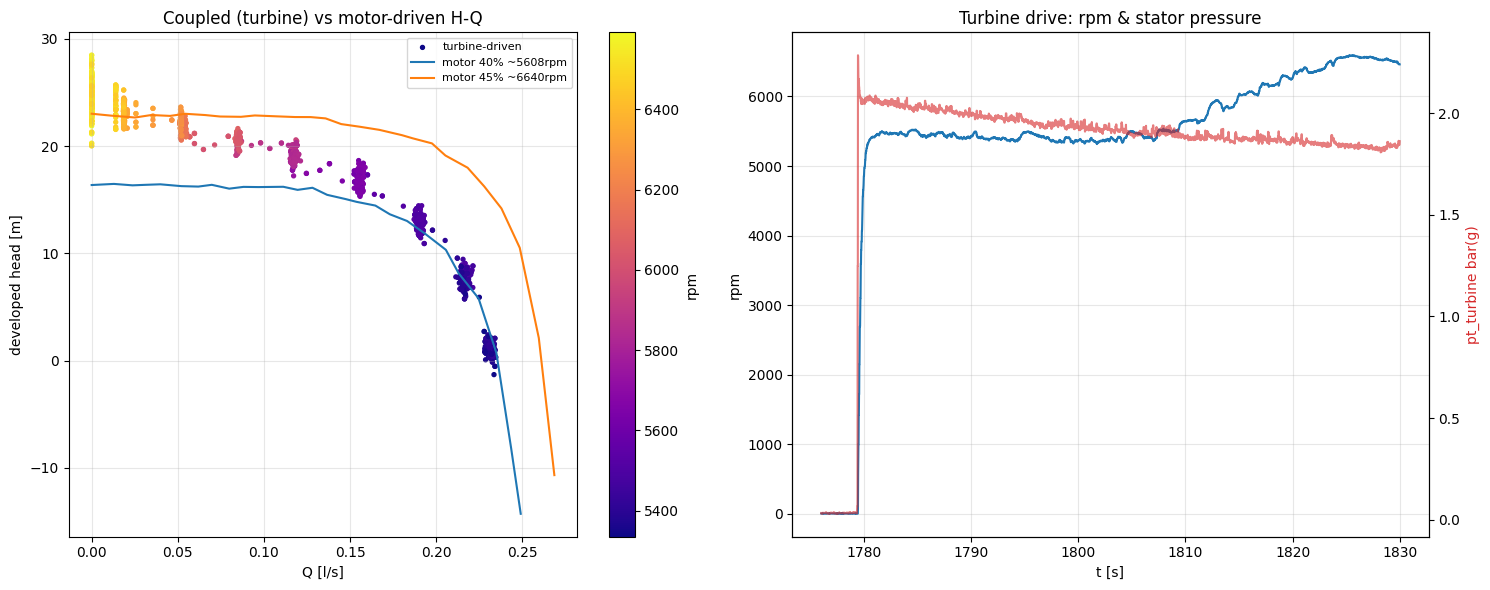

In [16]:
f=h5py.File(r'D:\\Projects\\propbackend_logs\\2026-06-05\\hotfirelog\\test_20260605_233937_HotfireLog.h5','r')
t=f['channels']['adc_rpm_mv']['time'][:]; m=(t>=1776)&(t<=1830)
def ch(n): return f['channels'][n]['data'][:][m]
rpm=ch('adc_rpm_mv'); q=ch('fms_fm0_flowrate'); H=ep.head_m(ch('adc_pt_out_mv')-ch('adc_pt_in_mv'))
ptt=ch('adc_pt_turbine_mv'); od=ch('servos_pumpoutlet_angle')
fig,(a1,a2)=plt.subplots(1,2,figsize=(15,6))
sel=(rpm>2000)&(H>-2)
a1.scatter(q[sel],H[sel],s=8,c=rpm[sel],cmap='plasma',label='turbine-driven')
# overlay motor-driven 40/45% (closest rpm)
for lbl in ['40%','45%']:
    e=EXP[lbl]; a1.plot(e['q'],e['H'],'-',lw=1.5,label=f'motor {lbl} ~{e["N"]:.0f}rpm')
a1.set(xlabel='Q [l/s]',ylabel='developed head [m]'); a1.grid(alpha=.3); a1.legend(fontsize=8); a1.set_title('Coupled (turbine) vs motor-driven H-Q')
cb=plt.colorbar(a1.collections[0],ax=a1); cb.set_label('rpm')
a2.plot(t[m],rpm,label='rpm'); a2.set_ylabel('rpm'); a2b=a2.twinx(); a2b.plot(t[m],ptt,color='tab:red',alpha=.6,label='pt_turbine'); a2b.set_ylabel('pt_turbine bar(g)',color='tab:red')
a2.set_xlabel('t [s]'); a2.set_title('Turbine drive: rpm & stator pressure'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Extrapolation to design speed (20,000 rpm)
H-Q by affinity (psi-phi invariant); efficiency by Reynolds step-up. vs Lock design point.

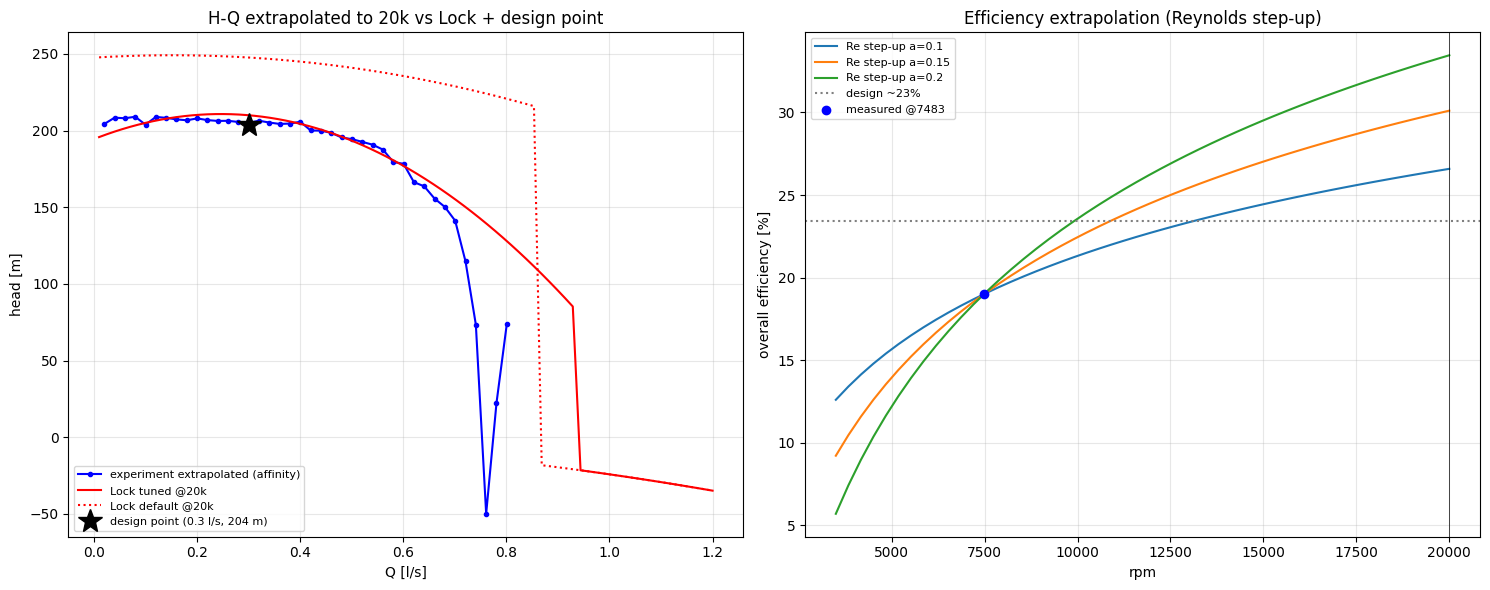

In [14]:
# affinity: take the experimental psi-phi master curve -> H-Q at 20k
N_DES=20000; u2d=np.pi*D2*N_DES/60
phi_grid=np.linspace(0.0005,0.02,40)
# fit a smooth psi(phi) to pooled experiment
order=np.argsort(PHI); ps=np.interp(phi_grid, PHI[order], PSI[order])
H_20k = ps*u2d**2/(2*G); Q_20k = phi_grid*np.pi*D2*B2*u2d*1000
fig,(a1,a2)=plt.subplots(1,2,figsize=(15,6))
a1.plot(Q_20k,H_20k,'b-o',ms=3,label='experiment extrapolated (affinity)')
qth=np.linspace(1e-5,0.0012,80); a1.plot(qth*1000,lock(qth,N_DES,K_FIT,ETAL_FIT)['H_static'],'r-',label='Lock tuned @20k')
a1.plot(qth*1000,lock(qth,N_DES,K_DEFAULT,ETAL_DEFAULT)['H_static'],'r:',label='Lock default @20k')
a1.plot([0.3],[203.9],'k*',ms=18,label='design point (0.3 l/s, 204 m)')
a1.set(xlabel='Q [l/s]',ylabel='head [m]'); a1.grid(alpha=.3); a1.legend(fontsize=8); a1.set_title('H-Q extrapolated to 20k vs Lock + design point')
# efficiency Reynolds step-up: (1-eta_D)/(1-eta_T)=(N_T/N_D)^a
eta_T=0.19; Ns=np.linspace(3500,20000,50)
for a in [0.1,0.15,0.2]:
    a2.plot(Ns,(1-(1-eta_T)*(7483/Ns)**a)*100,label=f'Re step-up a={a}')
a2.axhline(23.4,color='gray',ls=':',label='design ~23%'); a2.axvline(20000,color='k',lw=.5)
a2.scatter([7483],[19],c='b',zorder=5,label='measured @7483')
a2.set(xlabel='rpm',ylabel='overall efficiency [%]'); a2.grid(alpha=.3); a2.legend(fontsize=8); a2.set_title('Efficiency extrapolation (Reynolds step-up)')
plt.tight_layout(); plt.show()